# 04 — Warm-Start Fine-Tune

Before generating synthetic data at scale, we give the model a head start.

This notebook fine-tunes the base model on all knowledge pairs accumulated by
notebooks 03, 05, 06, 07, and 07b. After training, the model already understands
ARO syntax, knows the action vocabulary, and can produce valid programs — which
means notebook 08's RL explore loop starts with a much higher success rate instead
of failing constantly and learning nothing.

**Why LoRA?** It adapts the model with a tiny fraction of the parameters (rank 16,
16 layers), which fits in Apple Silicon unified memory and trains in minutes rather
than days. The adapter is saved and automatically loaded by every subsequent notebook.

**Run timing:** You can run notebook 04 as soon as notebook 03 finishes for a quick
warm-start. For best results, run it again after all of 05, 06, 07, and 07b have
appended their pairs — the more pairs the adapter sees, the better notebook 08 performs.

**Input:**  `../data/02_knowledge/knowledge_pairs.jsonl`
            `../data/02_knowledge/knowledge.json` (for system prompt)
**Output:** `../data/adapters/warm_start/` (LoRA adapter)
            `../data/02_knowledge/knowledge.json` (updated with adapter path)

In [20]:
import sys, importlib
from pathlib import Path
_cfg_dir = Path('.').resolve()
if _cfg_dir not in [Path(p) for p in sys.path]:
    sys.path.insert(0, str(_cfg_dir))
import config; importlib.reload(config); from config import *
print(f'Config loaded | model={MODEL_ID}')
print(f'ARO root:  {ARO_ROOT}')
print(f'Pairs:     {PAIRS_FILE}')
print(f'Adapters:  {ADAPTER_DIR}')

import gc, json, re, random, subprocess, sys
from pathlib import Path
from collections import Counter

with open(DATA_DIR / 'knowledge.json') as f:
    kb = json.load(f)

print(f'Knowledge pairs: {PAIRS_FILE}')
print(f'Adapter output:  {ADAPTER_DIR}')

Config loaded | model=mlx-community/Qwen3-Coder-30B-A3B-Instruct-4bit
ARO root:  /Users/kris/Projects/ARO-App
Pairs:     /Volumes/Models/data/../data/02_knowledge/knowledge_pairs.jsonl
Adapters:  /Volumes/Models/data/../data/adapters
Knowledge pairs: /Volumes/Models/data/../data/02_knowledge/knowledge_pairs.jsonl
Adapter output:  /Volumes/Models/data/../data/adapters


In [21]:
# Load all knowledge pairs produced by notebooks 03 and 05
all_pairs = []
with open(PAIRS_FILE) as f:
    for line in f:
        if line.strip():
            try:
                all_pairs.append(json.loads(line))
            except Exception:
                pass

sources = Counter(p['source'].split(':')[0] for p in all_pairs)
scores  = Counter(round(p.get('score', 1.0), 1) for p in all_pairs)

print(f'Total pairs: {len(all_pairs)}')
print('\nBy source:')
for src, n in sorted(sources.items(), key=lambda x: -x[1]):
    print(f'  {src:30s}: {n}')
print('\nBy score:')
for score, n in sorted(scores.items(), key=lambda x: -x[0]):
    print(f'  {score}: {n}')

Total pairs: 213

By source:
  example                       : 103
  proposal                      : 83
  book                          : 14
  aro_by_example                : 13

By score:
  1.0: 213


In [22]:
# Build system prompt from action metadata (same prompt used in notebooks 03 and 06)
action_lines = []
for a in kb['actions']:
    if a['verbs']:
        v = '/'.join(a['verbs'][:3])
        p = ', '.join(a['prepositions'][:4])
        action_lines.append(f'- {v}  (role: {a["role"]}, prepositions: {p})')

SYSTEM_PROMPT = f"""You are an expert ARO language programmer.
ARO (Action Result Object) is a DSL for business logic as natural-language statements.

SYNTAX:
  (FeatureSetName: BusinessActivity) {{
      Verb [the] <result[:qualifier]> preposition [the] <object[:qualifier]>.
  }}

KEY RULES:
- Articles (a/an/the) are optional
- String concatenation: ++ (NOT +)
- Variable names: hyphenated lowercase e.g. <user-id>, <order-total>
- Forbidden variable name prefixes: is-, with-, empty-
- Exactly ONE Application-Start per application
- openapi.yaml required for HTTP server; operationId must match feature set name
- Long-running apps: Keepalive the <application> for the <events>.
- Return statuses: <OK: status>, <Created: status>, <NotFound: status>
- HTTP path params: Extract the <id> from the <pathParameters: id>.
- Request body:     Extract the <data> from the <request: body>.

AVAILABLE ACTIONS:
{chr(10).join(action_lines[:40])}

Always wrap ARO code in ```aro ... ``` fences."""

print(f'System prompt: {len(SYSTEM_PROMPT)} chars')

System prompt: 3173 chars


## Warm-Start Fine-Tune

Fine-tune Qwen2.5-Coder on all extracted pairs so it understands ARO syntax
before notebook 06 starts generating synthetic data.

Uses 8 LoRA layers (same as the RL loop in notebook 06) with a conservative
learning rate of 1e-5 to prevent gradient instability on long sequences.
Sequences are truncated to 2048 tokens and `--grad-checkpoint` reduces peak memory.

The adapter is saved to `../data/adapters/warm_start/` and notebook 06
will automatically load it as the starting point for RL fine-tuning rounds.

Config loaded | model=mlx-community/Qwen3-Coder-30B-A3B-Instruct-4bit
ARO root:  /Users/kris/Projects/ARO-App
Pairs:     /Volumes/Models/data/../data/02_knowledge/knowledge_pairs.jsonl
Adapters:  /Volumes/Models/data/../data/adapters
Tokenizer loaded: mlx-community/Qwen3-Coder-30B-A3B-Instruct-4bit
Pairs after expansion: 223  (kept 190, split into 33, dropped 7)
After dedup: 204 (removed 19 duplicates)
SFT data: 174 train, 30 valid
Warm-start: 400 steps, 16 LoRA layers


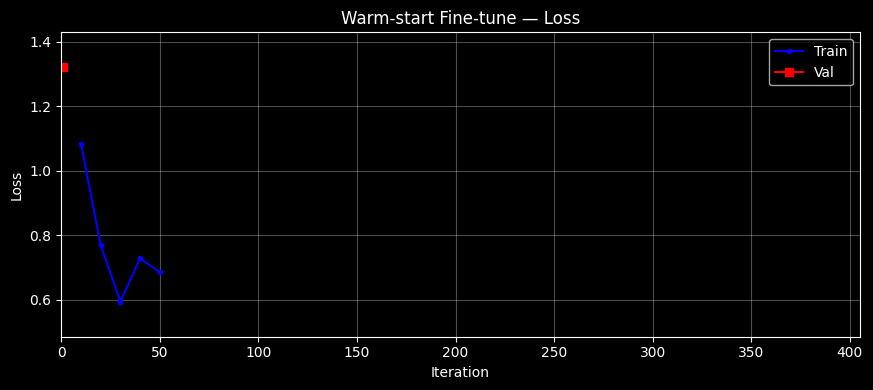

Fine-tuning:   0%|          | 0/400 [00:00<?, ?iter/s]

Running: /Applications/Xcode.app/Contents/Developer/usr/bin/python3 -m mlx_lm lora --model mlx-community/Qwen3-Coder-30B-A3B-Instruct-4bit --data /Volumes/Models/data/../data/warm_start_sft --train --num-layers 16 --iters 400 --batch-size 2 --learning-rate 1e-5 --adapter-path /Volumes/Models/data/../data/adapters/warm_start --mask-prompt --max-seq-length 2048 --grad-checkpoint --save-every 80 --val-batches 25
  /Library/Python/3.9/site-packages/urllib3/__init__.py:34: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
    warnings.warn(


Fine-tuning:   0%|          | 0/400 [00:00<?, ?iter/s]

  Loading pretrained model


Fine-tuning:   0%|          | 0/400 [00:01<?, ?iter/s]

...

  iter   30/400  │  train_loss 0.5950  │  lr 1.00e-05  │  0.064 it/s  │  52 tok/s  │  17364 tokens  │  mem 26.483 GB  │  ETA 1h36m


Fine-tuning:  10%|█         | 40/400 [11:22<1:34:01, 15.67s/iter, loss=0.729, it/s=0.074, mem_GB=26.483, ETA=1h21m]

  iter   40/400  │  train_loss 0.7290  │  lr 1.00e-05  │  0.074 it/s  │  30 tok/s  │  21480 tokens  │  mem 26.483 GB  │  ETA 1h21m


Fine-tuning:  12%|█▎        | 50/400 [13:30<1:25:23, 14.64s/iter, loss=0.686, it/s=0.078, mem_GB=26.483, ETA=1h14m]

  iter   50/400  │  train_loss 0.6860  │  lr 1.00e-05  │  0.078 it/s  │  25 tok/s  │  24681 tokens  │  mem 26.483 GB  │  ETA 1h14m


In [ ]:
import sys, importlib
from pathlib import Path
_cfg_dir = Path('.').resolve()
if _cfg_dir not in [Path(p) for p in sys.path]:
    sys.path.insert(0, str(_cfg_dir))
import config; importlib.reload(config); from config import *
print(f'Config loaded | model={MODEL_ID}')
print(f'ARO root:  {ARO_ROOT}')
print(f'Pairs:     {PAIRS_FILE}')
print(f'Adapters:  {ADAPTER_DIR}')

import os, warnings
os.environ.setdefault('TRANSFORMERS_NO_ADVISORY_WARNINGS', '1')
os.environ.setdefault('TOKENIZERS_PARALLELISM', 'false')
warnings.filterwarnings('ignore', message='.*IProgress not found.*')
warnings.filterwarnings('ignore', message='.*None of PyTorch.*')

import matplotlib.pyplot as plt
from IPython import display as ipydisplay
try:
    import ipywidgets
    from tqdm.notebook import tqdm as _tqdm_nb
    tqdm = _tqdm_nb
except Exception:
    from tqdm import tqdm

SFT_DIR = DATA_ROOT / 'warm_start_sft'
SFT_DIR.mkdir(parents=True, exist_ok=True)

import transformers
with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    _tok = transformers.AutoTokenizer.from_pretrained(MODEL_ID)
print(f'Tokenizer loaded: {MODEL_ID}')

MAX_TOKENS = 2000   # leave margin below 2048 hard limit

def _count_tokens(instruction, output):
    text = _tok.apply_chat_template([
        {'role': 'system',    'content': SYSTEM_PROMPT},
        {'role': 'user',      'content': instruction},
        {'role': 'assistant', 'content': output},
    ], tokenize=False, add_generation_prompt=False)
    return len(_tok.encode(text))

# ── Pre-process: split long pairs, keeping openapi.yaml with EVERY split ─────
# Multi-file HTTP pairs (## openapi.yaml + ## main.aro sections) are the most
# valuable training data. When splitting by file, always include the openapi
# preamble with each split so the model learns the contract↔feature-set link.

_file_section_re = re.compile(r'(##\s+\S+.*?)(?=\n##\s+\S+|\Z)', re.DOTALL)
_openapi_re      = re.compile(r'##\s+openapi\.yaml.*?(?=\n##\s+\S+|\Z)', re.DOTALL)

def _split_by_file(output):
    sections = _file_section_re.findall(output)
    return sections if len(sections) > 1 else []

def expand_pair(p):
    instruction, output = p['instruction'], p['output']

    if _count_tokens(instruction, output) <= MAX_TOKENS:
        return [(instruction, output)]

    sections = _split_by_file(output)
    if sections:
        # Extract the openapi.yaml section (if present) to prepend to ARO splits
        openapi_section = ''
        openapi_m = _openapi_re.search(output)
        if openapi_m:
            openapi_section = openapi_m.group(0).strip() + '\n\n'

        result = []
        for s in sections:
            if 'openapi.yaml' in s:
                # Keep openapi.yaml paired with the first .aro file if possible
                continue
            # Prepend openapi context to each ARO section
            combined = (openapi_section + s).strip() if openapi_section else s
            combined_instr = instruction + (' (see openapi.yaml above for contract)' if openapi_section else '')
            if _count_tokens(combined_instr, combined) <= MAX_TOKENS:
                result.append((combined_instr, combined))
            elif _count_tokens(instruction, s) <= MAX_TOKENS:
                result.append((instruction, s))
        if result:
            return result

    return []   # drop

expanded, stats = [], {'kept': 0, 'split': 0, 'dropped': 0}
for p in all_pairs:
    parts = expand_pair(p)
    if not parts:
        stats['dropped'] += 1
    elif len(parts) == 1 and parts[0][1] == p['output']:
        stats['kept'] += 1
        expanded.append({**p, 'instruction': parts[0][0], 'output': parts[0][1]})
    else:
        stats['split'] += len(parts)
        for instruction, output in parts:
            expanded.append({'instruction': instruction, 'output': output,
                             'source': p.get('source', ''), 'score': p.get('score', 1.0)})

print(f'Pairs after expansion: {len(expanded)}  '
      f'(kept {stats["kept"]}, split into {stats["split"]}, dropped {stats["dropped"]})')

# ── Deduplicate by instruction prefix ────────────────────────────────────────
seen_instr, deduped = set(), []
for p in expanded:
    key = p['instruction'][:120]
    if key not in seen_instr:
        seen_instr.add(key)
        deduped.append(p)
print(f'After dedup: {len(deduped)} (removed {len(expanded) - len(deduped)} duplicates)')
expanded = deduped

# ── Shuffle and split: 85% train, 15% valid ──────────────────────────────────
# 15% validation gives ~30+ samples for reliable loss measurement.
import random
random.shuffle(expanded)
split = max(4, int(len(expanded) * 0.15))

def pair_to_chat(p):
    return {'messages': [
        {'role': 'system',    'content': SYSTEM_PROMPT},
        {'role': 'user',      'content': p['instruction']},
        {'role': 'assistant', 'content': p['output']},
    ]}

(SFT_DIR / 'valid.jsonl').write_text(
    '\n'.join(json.dumps(pair_to_chat(p)) for p in expanded[:split]))
(SFT_DIR / 'train.jsonl').write_text(
    '\n'.join(json.dumps(pair_to_chat(p)) for p in expanded[split:]))

n_train = len(expanded) - split
iters   = max(100, min(400, n_train * 3))

print(f'SFT data: {n_train} train, {split} valid')
print(f'Warm-start: {iters} steps, 16 LoRA layers')

cmd = [
    sys.executable, '-m', 'mlx_lm', 'lora',
    '--model',          MODEL_ID,
    '--data',           str(SFT_DIR),
    '--train',
    '--num-layers',     '16',
    '--iters',          str(iters),
    '--batch-size',     '2',
    '--learning-rate',  '1e-5',
    '--adapter-path',   str(WARM_ADAPTER),
    '--mask-prompt',
    '--max-seq-length', '2048',
    '--grad-checkpoint',
    '--save-every',     str(max(50, iters // 5)),
    '--val-batches',    '25',
]

# ── Live loss graph ───────────────────────────────────────────────────────────
train_iters, train_losses = [], []
val_iters,   val_losses   = [], []

fig, ax = plt.subplots(figsize=(9, 4))
ax.set_xlabel('Iteration')
ax.set_ylabel('Loss')
ax.set_title('Warm-start Fine-tune — Loss')
ax.grid(True, alpha=0.3)
train_line, = ax.plot([], [], 'b-o', ms=3, lw=1.5, label='Train')
val_line,   = ax.plot([], [], 'r-s', ms=6, lw=1.5, label='Val')
ax.legend()
plt.tight_layout()

_fig_handle = ipydisplay.display(fig, display_id=True)

def _refresh_plot():
    if train_losses:
        train_line.set_data(train_iters, train_losses)
    if val_losses:
        val_line.set_data(val_iters, val_losses)
    all_y = train_losses + val_losses
    if all_y:
        lo, hi = min(all_y), max(all_y)
        pad = max(0.05, (hi - lo) * 0.15)
        ax.set_ylim(lo - pad, hi + pad)
    all_x = train_iters + val_iters
    if all_x:
        ax.set_xlim(0, max(iters, max(all_x)) + 5)
    fig.canvas.draw()
    _fig_handle.update(fig)

_train_re = re.compile(
    r'Iter\s+(\d+):\s+Train loss\s+([\d.]+)'
    r'(?:.*?Learning Rate\s+([\d.e+-]+))?'
    r'(?:.*?It/sec\s+([\d.]+))?'
    r'(?:.*?Tokens/sec\s+([\d.]+))?'
    r'(?:.*?Trained Tokens\s+([\d,]+))?'
    r'(?:.*?Peak mem\s+([\d.]+)\s*GB)?'
)
_val_re   = re.compile(r'Iter\s+(\d+):\s+Val loss\s+([\d.]+)(?:.*?Val took\s+([\d.]+)s)?')
_saved_re = re.compile(r'Adapter saved', re.IGNORECASE)

pbar      = tqdm(total=iters, desc='Fine-tuning', unit='iter', dynamic_ncols=True)
last_iter = 0

print('Running:', ' '.join(cmd))
proc = subprocess.Popen(
    cmd, stdout=subprocess.PIPE, stderr=subprocess.STDOUT,
    text=True, bufsize=1,
)
try:
    for raw_line in proc.stdout:
        line = raw_line.rstrip()

        m_train = _train_re.search(line)
        m_val   = _val_re.search(line)

        if m_train:
            it, loss    = int(m_train.group(1)), float(m_train.group(2))
            lr, it_sec  = m_train.group(3), m_train.group(4)
            tok_sec     = m_train.group(5)
            trained_tok = m_train.group(6)
            peak_mem    = m_train.group(7)

            train_iters.append(it)
            train_losses.append(loss)
            pbar.update(it - last_iter)
            last_iter = it

            eta_str = ''
            if it_sec:
                eta_s = (iters - it) / float(it_sec)
                h, r  = divmod(int(eta_s), 3600)
                m_, s = divmod(r, 60)
                eta_str = f'{h}h{m_:02d}m' if h else f'{m_}m{s:02d}s'

            postfix = {'loss': f'{loss:.3f}'}
            if it_sec:   postfix['it/s']   = it_sec
            if peak_mem: postfix['mem_GB'] = peak_mem
            if eta_str:  postfix['ETA']    = eta_str
            pbar.set_postfix(postfix)

            parts = [f'iter {it:>4}/{iters}', f'train_loss {loss:.4f}']
            if lr:          parts.append(f'lr {float(lr):.2e}')
            if it_sec:      parts.append(f'{float(it_sec):.3f} it/s')
            if tok_sec:     parts.append(f'{float(tok_sec):.0f} tok/s')
            if trained_tok: parts.append(f'{trained_tok.replace(",","")} tokens')
            if peak_mem:    parts.append(f'mem {peak_mem} GB')
            if eta_str:     parts.append(f'ETA {eta_str}')
            tqdm.write('  ' + '  │  '.join(parts))
            _refresh_plot()

        elif m_val:
            it, loss = int(m_val.group(1)), float(m_val.group(2))
            val_took = m_val.group(3)

            val_iters.append(it)
            val_losses.append(loss)
            pbar.set_postfix({'loss': f'{train_losses[-1]:.3f}' if train_losses else '?',
                              'val':  f'{loss:.3f}'})
            took_str = f'  ({val_took}s)' if val_took else ''
            tqdm.write(f'  ── val ──  iter {it:>4}/{iters}  val_loss {loss:.4f}{took_str}')
            _refresh_plot()

        elif _saved_re.search(line):
            tqdm.write(f'  ✓ {line}')
        elif line.strip():
            tqdm.write(f'  {line}')

finally:
    proc.wait()
    pbar.close()

_refresh_plot()

if proc.returncode == 0:
    print(f'\nWarm-start adapter saved to: {WARM_ADAPTER}')
else:
    print(f'\nFine-tune exited with code {proc.returncode}')


In [ ]:
# Update knowledge.json so notebook 06 finds the warm-start adapter automatically
kb['warm_start_adapter']    = str(WARM_ADAPTER)
kb['knowledge_pairs_file']  = str(PAIRS_FILE)
kb['knowledge_pairs_count'] = len(all_pairs)

with open(DATA_DIR / 'knowledge.json', 'w') as f:
    json.dump(kb, f, indent=2)

print('Updated knowledge.json')
print()
print('Next steps:')
print(f'  Adapter path: {WARM_ADAPTER}')
print(f'  Run notebook 06 — it will auto-load this adapter and run the RL explore loop')

In [ ]:
from pathlib import Path
import matplotlib.pyplot as plt
from datetime import date as _date

_run_dir = Path('.') / 'run' / _date.today().isoformat()
_run_dir.mkdir(parents=True, exist_ok=True)
_out = _run_dir / '04_warmstart_finetune.png'

if train_losses:
    # Re-draw the loss curves cleanly for the saved artefact
    fig2, ax2 = plt.subplots(figsize=(10, 5))
    ax2.plot(train_iters, train_losses, 'b-o', ms=3, lw=1.5, label='Train loss')
    if val_losses:
        ax2.plot(val_iters, val_losses, 'r-s', ms=7, lw=1.5, label='Val loss')
        ax2.axhline(min(val_losses), color='r', lw=0.8, ls='--', alpha=0.5,
                    label=f'Best val {min(val_losses):.4f}')
    ax2.set_xlabel('Iteration')
    ax2.set_ylabel('Loss')
    ax2.set_title(
        f'Warm-Start Fine-Tune — {n_train} pairs  ·  {iters} iters  ·  rank 16 / 16 layers',
        fontsize=13, fontweight='bold'
    )
    ax2.legend(fontsize=10)
    ax2.grid(alpha=0.3)
    ax2.set_facecolor('#f9f9f9')
    fig2.patch.set_facecolor('#fafafa')
    fig2.tight_layout()
    fig2.savefig(_out, dpi=150, bbox_inches='tight')
    plt.show()
    plt.close(fig2)
    print(f'Saved: {_out}')
else:
    print('No training data to plot — run the fine-tune cell first.')